# Project 1 – XAI: Logistic Regression on diabetes data
Simple setup: 80/20 train/test split, standardization, sklearn `LogisticRegression` trained epoch by epoch with early stopping, followed by testing and loss evaluation.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, confusion_matrix, classification_report
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
import seaborn as sns

# we deliberately run 1 iteration per call, so sklearn will warn every time - hide that
warnings.filterwarnings("ignore", category=ConvergenceWarning)

### Adjustable parameters

In [2]:
# split
test_size = 0.20          # 80/20 train/test
val_size = 0.20           # fraction of the TRAINING data used for validation (early stopping)
seed = 420

# training
max_epochs = 100
C_reg = 1.0               # inverse regularization strength (smaller = stronger regularization)

# early stopping
patience = 5              # epochs without improvement before stopping
min_delta = 1e-5          # minimum decrease in val loss to count as an improvement

In [3]:
# Load data
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

feature_names = list(df.columns)
feature_names.remove("Diabetes_binary")

X = df[feature_names].values
y = df["Diabetes_binary"].values.astype(int)

print(f"X: {X.shape}, y: {y.shape}")
print(f"Classes: {np.bincount(y)}")

X: (70692, 21), y: (70692,)
Classes: [35346 35346]


In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


### Train/test split (80/20)
The test set is not touched until the end. Early stopping needs data the model is not trained on, so a validation set is taken out of the training data.

In [5]:
# 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=seed, stratify=y)

# validation set taken from the training data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=val_size, random_state=seed, stratify=y_train)

print(f"Train: {X_train_raw.shape[0]}, Val: {X_val_raw.shape[0]}, Test: {X_test_raw.shape[0]}")

Train: 45242, Val: 11311, Test: 14139


### Standardization
Mean and std are computed on the training data only and then applied to val and test, so no information leaks from the test set.

In [6]:
train_mean = np.mean(X_train_raw, axis=0)
train_std = np.std(X_train_raw, axis=0)

X_train = (X_train_raw - train_mean) / train_std
X_val = (X_val_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

print("Train mean:", np.round(np.mean(X_train, axis=0), 3))
print("Train std: ", np.round(np.std(X_train, axis=0), 3))

Train mean: [ 0. -0. -0.  0. -0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0.  0.  0. -0.
  0.  0.  0.]
Train std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 2. Run (training with early stopping)
sklearn's `LogisticRegression` has no built-in early stopping. Instead we use:
- `max_iter=1`, so each call to `.fit()` performs one optimization step (we call each step an epoch)
- `warm_start=True`, so each call continues from the previous weights instead of starting over

After each epoch the log loss on the validation set is computed. If it has not improved by at least `min_delta` for `patience` epochs, training stops and the best weights are restored.

In [7]:
model = LogisticRegression(solver='lbfgs', max_iter=1, warm_start=True,
                           C=C_reg, random_state=seed)

train_losses = []
val_losses = []

best_val_loss = np.inf
best_coef = None
best_intercept = None
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(max_epochs):
    # one epoch of training
    model.fit(X_train, y_train)

    # loss on train and validation
    train_loss = log_loss(y_train, model.predict_proba(X_train))
    val_loss = log_loss(y_val, model.predict_proba(X_val))
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # early stopping check
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_coef = model.coef_.copy()
        best_intercept = model.intercept_.copy()
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement = epochs_without_improvement + 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# restore the best weights
model.coef_ = best_coef
model.intercept_ = best_intercept

print(f"Best epoch: {best_epoch}, val loss: {best_val_loss:.4f}")

Early stopping at epoch 8
Best epoch: 3, val loss: 0.5102


## 3. Testing

In [8]:
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

train_acc = np.mean(train_pred == y_train)
val_acc = np.mean(val_pred == y_val)
test_acc = np.mean(test_pred == y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Val accuracy:   {val_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.746
Val accuracy:   0.754
Test accuracy:  0.750


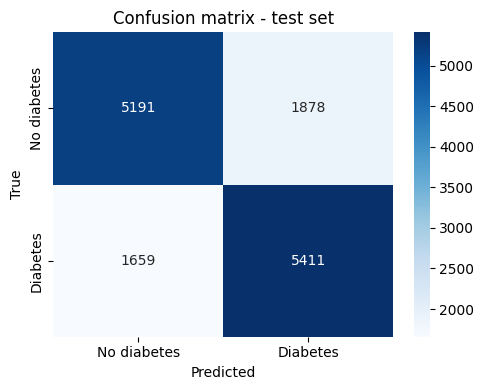

              precision    recall  f1-score   support

 No diabetes       0.76      0.73      0.75      7069
    Diabetes       0.74      0.77      0.75      7070

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [9]:
# Confusion matrix + classification report on the test set
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No diabetes', 'Diabetes'],
            yticklabels=['No diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix - test set')
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred, target_names=['No diabetes', 'Diabetes']))

## 4. Loss evaluation

In [10]:
# final loss on each set (with the best weights)
final_train_loss = log_loss(y_train, model.predict_proba(X_train))
final_val_loss = log_loss(y_val, model.predict_proba(X_val))
final_test_loss = log_loss(y_test, model.predict_proba(X_test))

print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss:   {final_val_loss:.4f}")
print(f"Test loss:  {final_test_loss:.4f}")

Train loss: 0.5138
Val loss:   0.5102
Test loss:  0.5089


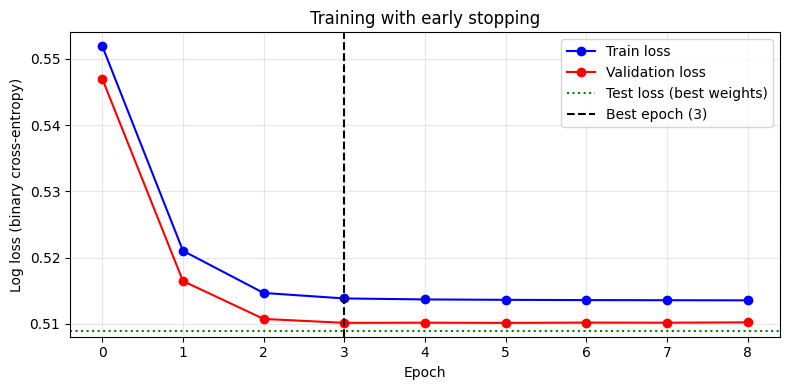

In [11]:
# Loss curves
epochs = np.arange(len(train_losses))

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, 'o-', label='Train loss', color='blue')
plt.plot(epochs, val_losses, 'o-', label='Validation loss', color='red')
plt.axhline(final_test_loss, color='green', linestyle=':', label='Test loss (best weights)')
plt.axvline(best_epoch, color='black', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Log loss (binary cross-entropy)')
plt.title('Training with early stopping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()